In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# 'RELIANCE.NS' targets Reliance on the National Stock Exchange of India
ticker = "RELIANCE.NS"

print(f"Downloading data for {ticker}...")
data = yf.download(ticker, start="2021-05-18", end="2026-05-18")

print("\n--- First 5 Rows of Data ---")
print(data.head())
print(data.tail())

print("---Info---")
print(data.info())

[*********************100%***********************]  1 of 1 completed


--- First 5 Rows of Data ---
Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2021-05-18  901.398743  908.041525  894.393214  898.247421    12064918
2021-05-19  905.524841  914.321435  894.166413  897.793820    16317002
2021-05-20  900.242432  911.804932  898.247354  905.910312    11422532
2021-05-21  908.018738  911.215395  900.514456  903.235026    10785605
2021-05-24  900.355774  911.306181  898.700776  910.489956     8551760
Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2026-05-11  1388.199951  1428.000000  1382.000000  1420.000000    15261787
2026-05-12  1364.000000  1393.500000  1360.300049  1392.000000    24357500
2026-05-13  1358.800049  13

In [2]:
# 1. Use .squeeze() for removig the unnecessary dimensional vectors
adj_close = data['Close'].squeeze()

print("-----------Summary Statistics---------")
print(adj_close.describe())

# 2 Check for missing data
print(data.isnull().sum())

# 3. Calculate variance (this will now be a single number scalar!)
variance = adj_close.var()
print(f"\nAsset Variance: {variance:.2f}")

-----------Summary Statistics---------
count    1237.000000
mean     1257.147684
std       162.437182
min       890.153625
25%      1132.248657
50%      1228.714478
75%      1408.800049
max      1592.300049
Name: RELIANCE.NS, dtype: float64
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

Asset Variance: 26385.84


In [3]:
# Find the exact dates of the highest and lowest prices
highest_price_date = adj_close.idxmax()
lowest_price_date = adj_close.idxmin()

# Find the exact prices on those dates
highest_price = adj_close.max()
lowest_price = adj_close.min()

print(f"5-Year High: INR {highest_price:.2f} on {highest_price_date.strftime('%Y-%m-%d')}")
print(f"5-Year Low:  INR {lowest_price:.2f} on {lowest_price_date.strftime('%Y-%m-%d')}")

mean_val = adj_close.mean()
median_val = adj_close.median()

print(f"\nMean Price: INR {mean_val:.2f}")
print(f"Median Price: INR {median_val:.2f}")

if mean_val > median_val:
    print("Insight: The data is positively skewed. Heavy upward rallies are pulling the average up.")
else:
    print("Insight: The data is negatively skewed or symmetric.")
    

5-Year High: INR 1592.30 on 2026-01-02
5-Year Low:  INR 890.15 on 2021-05-25

Mean Price: INR 1257.15
Median Price: INR 1228.71
Insight: The data is positively skewed. Heavy upward rallies are pulling the average up.


In [4]:
# 1. Calculate percentage change row-by-row on our squeezed Close prices
daily_returns = adj_close.pct_change()

print("--- Raw Daily Returns Table ---")
print(daily_returns.head())

# 2. THE PITFALL: Look at the very first row. It will say 'NaN' 
# Why? Because the first day has no "yesterday" to calculate a change from!
# We must clean this using .dropna() or our future math will break.

clean_returns = daily_returns.dropna()

print("\n--- Cleaned Summary Statistics for Returns ---")
print(clean_returns.describe())

# 3. Scale up the metrics to make them human-readable
print(f"\nMaximum Single-Day Gain: {clean_returns.max() * 100:.2f}%")
print(f"Maximum Single-Day Loss: {clean_returns.min() * 100:.2f}%")

--- Raw Daily Returns Table ---
Date
2021-05-18         NaN
2021-05-19    0.004577
2021-05-20   -0.005834
2021-05-21    0.008638
2021-05-24   -0.008439
Name: RELIANCE.NS, dtype: float64

--- Cleaned Summary Statistics for Returns ---
count    1236.000000
mean        0.000419
std         0.014173
min        -0.074851
25%        -0.007983
50%         0.000571
75%         0.007882
max         0.070192
Name: RELIANCE.NS, dtype: float64

Maximum Single-Day Gain: 7.02%
Maximum Single-Day Loss: -7.49%


In [5]:
daily_volatility = clean_returns.std()
print(f"Standard deviation of eveeryday return: {daily_volatility * 100:.2f}%")

Standard deviation of eveeryday return: 1.42%


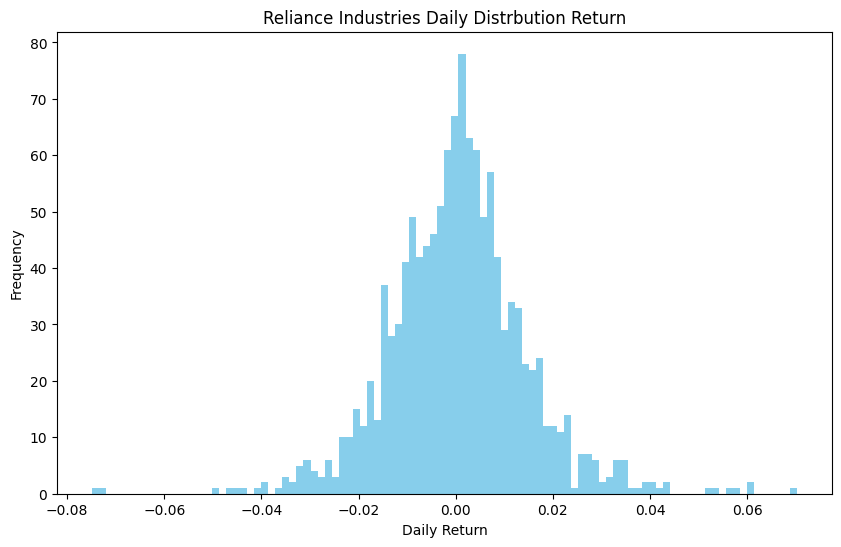

avr = 22.49


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(clean_returns, bins=100 , color = 'skyblue')
plt.title("Reliance Industries Daily Distrbution Return")
plt.ylabel("Frequency")
plt.xlabel("Daily Return")
plt.show()

annualized_volatility_rate = daily_volatility*15.87
print(f"avr = {annualized_volatility_rate * 100:.2f}")

In [7]:
log_returns = np.log(adj_close) - np.log(adj_close.shift(1))
clean_log_returns = log_returns.dropna()

slice_start, slice_end = 5,10;

summed_log_return = clean_log_returns.iloc[slice_start:slice_end].sum()

price_start = adj_close.iloc[slice_start]
price_end = adj_close.iloc[slice_end]
direct_log_return = np.log(price_end / price_start)

skew = clean_log_returns.skew()
kurtosis = clean_log_returns.kurtosis()

print(f"Summed Daily Log Returns: {summed_log_return:.6f}")
print(f"Direct Period Log Return: {direct_log_return:.6f}")

print(f"Log Return Skewness     : {skew:.4f}")
print(f"Excess Kurtosis (Tails) : {kurtosis:.4f}")

if kurtosis > 0:
    print("Insight: The asset exhibits Leptokurtosis (Fat Tails).")
    print("Standard risk models will structurally underestimate the chance of a market crash.")

Summed Daily Log Returns: 0.099670
Direct Period Log Return: 0.099670
Log Return Skewness     : 0.0284
Excess Kurtosis (Tails) : 2.8244
Insight: The asset exhibits Leptokurtosis (Fat Tails).
Standard risk models will structurally underestimate the chance of a market crash.


In [8]:
# STEP 1: Calculate a 20-Day Rolling Mean (Simple Moving Average)
# TODO: Use .rolling() with a window of 20 and apply the mean function to adj_close.
# Save it into a new column inside your dataframe called data['SMA_20']
data['SMA_20'] = adj_close.rolling(window = 20).mean()


# STEP 2: Calculate a 20-Day Rolling Volatility (Standard Deviation)
# TODO: Use .rolling() with a window of 20 and apply the standard deviation (.std()) function.
# Save it into a new column called data['Rolling_Vol_20']
data['Rolling_Vol_20'] = adj_close.rolling(window=20).std()


print("--- 20-Day Rolling Window Framework ---")
# This prints out a slice where the rolling windows have enough data to compute
print(data[['Close', 'SMA_20', 'Rolling_Vol_20']].dropna().head(10))


# STEP 3: Fetch the latest data point for our trading signal
# We use .iloc[-1] to grab the very last row (today's live market data)
latest_row = data.iloc[-1]
current_price = latest_row['Close'].squeeze()
current_sma = latest_row['SMA_20'].squeeze()


print("\n=========================================")
print("       📡 ALGORITHMIC TREND SIGNAL       ")
print("=========================================")
print(f"Current Closing Price : INR {current_price:.2f}")
print(f"20-Day Moving Average : INR {current_sma:.2f}")
print("-----------------------------------------")


# STEP 4: Write the Conditional Trading Logic
# TODO: Write an if/else block:
# - IF current_price is greater than current_sma: Print a BULLISH momentum message.
# - ELSE: Print a BEARISH momentum message.
# WRITE YOUR CODE HERE

if(current_price>current_sma):
    print("Signal: Bullish Momentum-> The current price is higher than the average of the previous trend:")
else:
    print("Signal: Bearish Momentum-> The current price is lower than the average of the previous trend ")


print("=========================================")

--- 20-Day Rolling Window Framework ---
Price             Close      SMA_20 Rolling_Vol_20
Ticker      RELIANCE.NS                           
Date                                              
2021-06-14  1021.456421  955.989343      49.574941
2021-06-15  1023.777100  962.108261      50.032644
2021-06-16  1006.304565  967.147247      49.100244
2021-06-17  1008.147339  972.542493      47.255423
2021-06-18  1012.697449  977.776428      45.497050
2021-06-21  1017.975647  983.657422      42.463574
2021-06-22  1012.742981  989.786890      36.714796
2021-06-23  1003.460754  995.295816      28.908575
2021-06-24   979.868408  999.487958      17.637208
2021-06-25   957.550049  999.873068      16.546635

       📡 ALGORITHMIC TREND SIGNAL       
Current Closing Price : INR 1336.40
20-Day Moving Average : INR 1391.84
-----------------------------------------
Signal: Bearish Momentum-> The current price is lower than the average of the previous trend 
